# Extract microscopic diffusion parameters $(s, \epsilon)$ from single-fish data 
See Puri, et. al, PRL (2026) Supplementary Material (Sec. 3.2) for details of the fitting procedure 


In [18]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import h5py
import datetime
from scipy.special import comb
from itertools import combinations

import sys
sys.path.append('../..')
from codebase.subgroup_analysis import annotate_subgroups_framewise
from codebase.parameter_fitting import get_single_fish_dtheta_vs_dt, get_MSD_dtheta_vs_dt, fit_MSD_slope_linear_regime, fit_s_epsilon_jointly_bounded

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
data_path = '../../Data/groups_by_age/'
exp_details = pd.read_csv(data_path + 'exp_details.csv')
fish_ages = [2,4,6,8]
L = 50 # mm
fps = 121 # Hz
dt_for_v = 60 # frames skipped for velocity calculation, ~0.5s

mesoscopic_params_full_dataset = pd.read_csv("../../Results/mesoscopic_params_L50_full_dataset.csv").to_numpy()

# Calculate $\Delta\theta (dt)$ for $N_G=1$ (single fish) in each experiment
Also compute fish velocity

In [5]:
T_max = 2 #s
dt_array = np.arange(int(0.01*fps), int(T_max*fps), 1) # in frames, 0.01s to 2s

dtheta_vs_dt_all_ages = {age: [] for age in fish_ages}
v_values_all_ages = {age: [] for age in fish_ages}

for j,age in enumerate(fish_ages):
    exp_list = np.flatnonzero(exp_details['fish_age']==age)
    dtheta_expwise = []
    v_expwise = []
    
    for exp in exp_list:
        fpath = f'{data_path}h5_files_cleaned/{exp_details["experiment"][exp]}.h5'
        f = h5py.File(fpath,'r')
        nfish = 4

        x = f['tracks'][:nfish,0,:,:] #array of shape (fish x nodes x frames)
        y = f['tracks'][:nfish,1,:,:]
        nose_x = (x[:,0,:] + x[:,1,:])/2 # avg L and R eye positions to get nose position
        nose_y = (y[:,0,:] + y[:,1,:])/2

        # calculate linear velocity for all fish & frames
        vx = (nose_x[:,dt_for_v:] - nose_x[:,:-dt_for_v])/dt_for_v * fps
        vy = (nose_y[:,dt_for_v:] - nose_y[:,:-dt_for_v])/dt_for_v * fps
        v_expwise.append(np.sqrt(vx**2 + vy**2).reshape(-1))

        # heading angles by calculating angle between nose and mid-bladder (node index 3)
        # mid-bladder is a more stable reference point than tail 
        head_angles = np.arctan2(nose_y - y[:,3,:],nose_x - x[:,3,:])

        subgroups, start_end_frames = annotate_subgroups_framewise(nose_x, nose_y, L)
        subgroup_sizes = np.array([len(s) for s in subgroups])
        subgroup_times = start_end_frames[:,1] - start_end_frames[:,0] # in frames

        # select Ng=1 (single fish) subgroups that exist for atleast dt_array[0] frames
        selected_idx = np.flatnonzero(np.logical_and(subgroup_sizes == 1, subgroup_times>dt_array[0]))
        subgroups = [subgroups[i] for i in selected_idx]
        start_end_frames = start_end_frames[selected_idx,:]

        # calculate dtheta vs dt for single fish subgroups
        dtheta_expwise.append(get_single_fish_dtheta_vs_dt(subgroups, start_end_frames, head_angles, dt_array))
    
    # save results 
    dtheta_vs_dt_all_ages[age] = dtheta_expwise
    v_values_all_ages[age] = v_expwise

# Angular mean squared displacement, i.e., $\langle\Delta\theta^2(dt)\rangle$ for full dataset
MSD vs $dt$ is super-linear at short times, due to correlations between $\Delta \theta$ during turning events. At long times, MSD grows linearly with $dt$, as expected for simple angular diffusion (single fish, no copying interactions). We will identify the start of the linear regime by fitting the "knee" of the MSD vs $dt$ curve. 

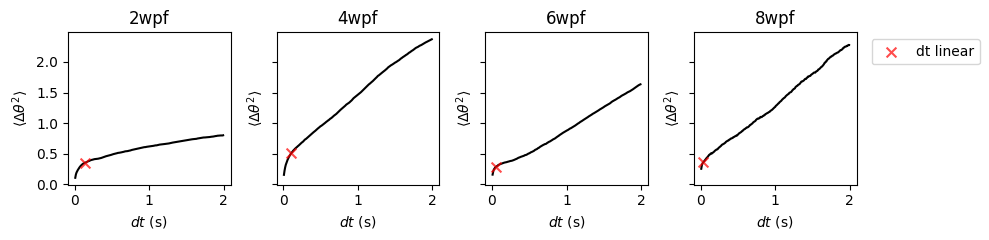

In [49]:
MSD_vs_t_all_ages = {age: [] for age in fish_ages}
for j,age in enumerate(fish_ages):
    dtheta_vs_t = np.concatenate(dtheta_vs_dt_all_ages[age], axis=0)
    MSD_vs_t, n_data_points = get_MSD_dtheta_vs_dt(dtheta_vs_t)
    MSD_vs_t_all_ages[age] = MSD_vs_t

dt_linear = np.zeros((len(fish_ages))) 
fig, ax = plt.subplots(1,4, figsize=(10,2.5), sharey='row', sharex='col')
for i, age in enumerate(fish_ages):  
    t = MSD_vs_t_all_ages[age][:,0]/fps
    y = MSD_vs_t_all_ages[age][:,1]

    first_derivative = np.gradient(y,t)
    second_derivative = np.gradient(first_derivative,t)

    ax[i].plot(t, y, color='k')
    ax[i].set_title(f'{age}wpf')

    # locate knee using first zero crossing of second derivative
    zero_crossings = np.where(np.diff(np.sign(second_derivative)))[0]
    if len(zero_crossings) > 0:
        ind = zero_crossings[0]
        ax[i].scatter(t[ind], y[ind], color='r',marker='x', s=50, label='dt linear',zorder=10, alpha=0.7)
        dt_linear[i] = t[ind]

    ax[i].set_ylabel(r'$\langle\Delta\theta^2\rangle$')
    ax[i].set_xlabel('$dt$ (s)')
ax[-1].legend(loc='upper left', bbox_to_anchor=(1.05, 1), fontsize=10)
fig.tight_layout()

### For self-consistency, the rate of diffusion events is upper bounded $s\leq1/dt_{\mathrm{linear}}$

In [50]:
s_max = 1/dt_linear

# Fit microscopic parameters $(s,\epsilon)$ for full dataset

In [51]:
microscopic_params_full_dataset = np.zeros((len(fish_ages), 4)) # columns: s, epsilon, beta, v

In [59]:
for j, age in enumerate(fish_ages):
    MSD_slope = fit_MSD_slope_linear_regime(MSD_vs_t_all_ages[age], dt_linear[j])
    s_eps_fit = fit_s_epsilon_jointly_bounded(alpha=mesoscopic_params_full_dataset[j,0], slope=MSD_slope, s_upper_bound=s_max[j])
    # velocity averaged over all experiments
    v  = np.nanmean(np.concatenate(v_values_all_ages[age], axis=0))

    microscopic_params_full_dataset[j,:] = [s_eps_fit[0], s_eps_fit[1], mesoscopic_params_full_dataset[j,1], v]

In [60]:
# write to file
np.savetxt(f'../../Results/microscopic_params_L50_full_dataset.csv', microscopic_params_full_dataset, delimiter=',', header='s,epsilon,beta,v')